# Setup

In [14]:
%load_ext autoreload
%autoreload 2

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow import keras

from utils.feature_importance_utils import (
    block_shuffle_1d,
    permutation_importance_global_sequence,
)

from utils.feature_utils import (
    get_condition_aware_labels,
    normalize_train_labels,
    get_iter_acc_without_switches,
    get_iter_acc_with_switches,
    extract_features_blockless,
)


print("tf:", tf.__version__)
print("keras:", keras.__version__)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
tf: 2.20.0
keras: 3.13.2


# Load features and model

In [2]:
model_name = "rlf"
N_AGENTS = 500
num_blocks = 12
max_num_trials = 78
suffix = '3ParamRL_no_switch_st22'
filename = f"./data/{model_name}_6s3a/{N_AGENTS}a_{num_blocks}b_{max_num_trials}t_{suffix}.csv"
print(filename)
test_data = pd.read_csv(filename)

./data/rlf_6s3a/500a_12b_78t_3ParamRL_no_switch_st22.csv


## Parameter Estimation

In [50]:
from tensorflow.python.keras.utils.generic_utils import register_keras_serializable
from tensorflow import keras


@register_keras_serializable
def gaussian_kl_loss(y_true, y_pred):
    """
    Custom loss function for KL divergence between two Gaussian distributions.
    Assumes y_pred contains both mean and log variance predictions.
    """
    # Split the prediction into mean and log variance
    # First half of output_dims for mean, second half for log variance
    n_dims = tf.shape(y_true)[1]
    mu = y_pred[:, :n_dims]
    log_var = y_pred[:, n_dims:]

    # Stabilize log variance to prevent numerical issues
    log_var = tf.clip_by_value(log_var, -10.0, 10.0)

    # Calculate KL divergence between predicted Gaussian and true values
    # Formula: KL(N(µ_true,I) || N(µ_pred,σ²_pred)) =
    #   0.5 * (tr(σ²_pred^-1) + ||µ_true - µ_pred||²/σ²_pred - k - log|σ²_pred|)
    # Where k is the dimensionality

    # For Gaussian with fixed unit variance as target:
    kl_loss = 0.5 * tf.reduce_sum(
        -log_var + tf.exp(log_var) + tf.square(mu - y_true) - 1.0,
        axis=1
    )
    return tf.reduce_mean(kl_loss)

def sample_from_model(model, x, n_samples=1):
    """
    Generate samples from the predicted Gaussian distribution
    """
    prediction = model.predict(x)
    n_dims = prediction.shape[1] // 2

    # Extract mean and variance
    mean = prediction[:, :n_dims]
    log_var = prediction[:, n_dims:]
    std = tf.exp(0.5 * log_var)

    # Sample from the distribution
    eps = tf.random.normal(shape=(x.shape[0], n_samples, n_dims))
    samples = mean[:, tf.newaxis, :] + eps * std[:, tf.newaxis, :]

    return samples, mean, std

def build_mean_only_wrapper(base_model, y_val):
    from keras import layers
    """
    base_model output: [..., 2*D] = [mu, log_var]
    wrapper output:    [..., D]   = mu only
    """
    # infer target dims from y
    target_dims = y_val.shape[-1]
    inp = keras.Input(shape=base_model.input_shape[1:])
    out = base_model(inp, training=False)
   # If model output is a list/tuple, pick the prediction tensor
    if isinstance(out, (list, tuple)):
        out = out[0]    
    # take mean part only (first D channels)
    mu = out[..., :target_dims]
    #mu = layers.Lambda(lambda z: z[..., :target_dims], name="mu_only")(out)
    mean_model = keras.Model(inp, mu, name="mean_only_wrapper")
    mean_model.compile(loss="mse")  # compile for evaluate(); no training happens
    return mean_model

In [53]:
beta_multiplier = 20
feature_list = ['actions', 'rewards',  'stim_iter', 'isswitch', 'prev_action', 'delay_since_last_stimuli']

has_switches = (test_data.isswitch.nunique() == 2)
test_iter = get_iter_acc_with_switches(test_data) if has_switches else get_iter_acc_without_switches(test_data)
test_iter['isswitch'] = test_iter['trials'].apply(lambda x: 1 if x == 0 else 0)
test_iter['prev_action'] = test_data.groupby(['agentid', 'block_no'])['actions'].shift(1).fillna(-1).astype(int).to_list()
test_iter['delay_since_last_stimuli'] = test_data['delay_since_last_stimuli'].to_list()
test_iter['prev_action'] = test_data.groupby(['agentid', 'block_no'])['actions'].shift(1).fillna(-1).astype(int).to_list()

sorted_col = ['agentid', 'block_no', 'stimuli']
test_iter_order = test_iter.sort_values(by=sorted_col)
test_features = extract_features_blockless(test_iter_order, feature_list, [])

shared, conditioned = ['beta', 'alpha', 'phi', 'stickiness'], []
raw_test_labels = get_condition_aware_labels(test_data, shared, conditioned)
if 'beta' in raw_test_labels:
  raw_test_labels['beta'] = raw_test_labels['beta']/beta_multiplier

test_labels, name_to_scaler = normalize_train_labels(raw_test_labels)  

In [40]:
model_name = "ds_3000a_12b_78t_3ParamRL_no_switch_st22_B128_U96_D0.128_D0.051_D0.15_0.002_model.keras"
custom_objects = {'gaussian_kl_loss': gaussian_kl_loss}
gru_model = tf.keras.models.load_model(f"./models/{model_name}", compile=False, custom_objects=custom_objects)

In [54]:
mean_model = build_mean_only_wrapper(gru_model, test_labels)
ranking = permutation_importance_global_sequence(
    model=mean_model,
    X_val=test_features,
    y_val=test_labels,
    feature_names=feature_list,
    n_repeats=3,
    batch_size=64,
    shuffle_mode="within_sample",
    block_size=32,
    random_state=123
)

Permutation feature actions
Permutation loss: 0.695829451084137
Permutation loss: 0.6720670461654663
Permutation loss: 0.681053876876831
Permutation feature rewards
Permutation loss: 1.328613519668579
Permutation loss: 1.3316020965576172
Permutation loss: 1.328237533569336
Permutation feature stim_iter
Permutation loss: 1.5870311260223389
Permutation loss: 1.5952322483062744
Permutation loss: 1.596957802772522
Permutation feature isswitch
Permutation loss: 0.4058915376663208
Permutation loss: 0.4065372347831726
Permutation loss: 0.4054376780986786
Permutation feature prev_action
Permutation loss: 0.6974431872367859
Permutation loss: 0.6915324926376343
Permutation loss: 0.6957285404205322
Permutation feature delay_since_last_stimuli
Permutation loss: 0.9271889925003052
Permutation loss: 0.9181827306747437
Permutation loss: 0.9200085401535034


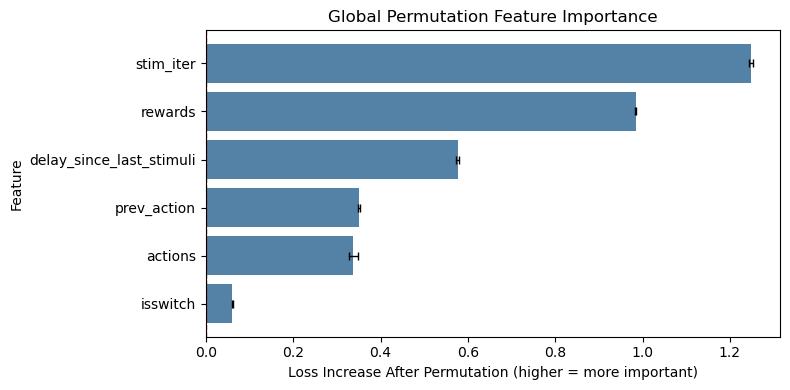

In [55]:
plt.figure(figsize=(8, 4))
ax = sns.barplot(
    data=ranking,
    x="importance_mean",
    y="feature",
    color="steelblue"
)
# add error bars if present
if "importance_std" in ranking.columns:
    ax.errorbar(
        x=ranking["importance_mean"],
        y=range(len(ranking)),
        xerr=ranking["importance_std"],
        fmt="none",
        ecolor="black",
        capsize=3,
        lw=1
    )
ax.axvline(0, color="red", linestyle="--", linewidth=1)
ax.set_title("Global Permutation Feature Importance")
ax.set_xlabel("Loss Increase After Permutation (higher = more important)")
ax.set_ylabel("Feature")
plt.tight_layout()
plt.show()

## LaseNet

In [ ]:
%matplotlib inline
import warnings; warnings.simplefilter('ignore')  # hide warnings
feature_list = ['actions', 'rewards',  'stimuli','isswitch','delay_since_last_stimuli']

has_switches = (test_data.isswitch.nunique() == 2)
test_iter = get_iter_acc_with_switches(test_data) if has_switches else get_iter_acc_without_switches(test_data)
test_iter['isswitch'] = test_iter['trials'].apply(lambda x: 1 if x == 0 else 0)
test_iter['prev_action'] = test_data.groupby(['agentid', 'block_no'])['actions'].shift(1).fillna(-1).astype(int).to_list()
test_iter['delay_since_last_stimuli'] = test_data['delay_since_last_stimuli'].to_list()

test_features = extract_features_blockless(test_iter, feature_list, [])

num_test_agents = test_data['agentid'].nunique()
n_trial = test_data['trials'].nunique()
n_block = test_data['block_no'].nunique()
qv = np.array(test_data['rewards'] - test_data['rpe_history'])
test_labels = qv.astype(np.float32).reshape((num_test_agents, n_block*n_trial))

print(test_features.shape, test_labels.shape)

(500, 936, 5) (500, 936)


In [5]:
model_name = "lasenet_RLF-6S3A_a-r-s-i-d_A3000_936t_B128_U256_D0.097_D0.013_D0.011_0.000696_model.keras"
gru_model = tf.keras.models.load_model(f"./models/{model_name}", compile=True)

# Evaluate

## Block size shuffle

In [7]:
block_sizes = [16, 32, 64]
all_rankings = {}
for bs in block_sizes:
    ranking_bs = permutation_importance_global_sequence(
        model=gru_model,
        X_val=test_features,
        y_val=test_labels,
        feature_names=feature_list,
        n_repeats=3,
        batch_size=128,
        sample_weight=None,
        shuffle_mode="within_sample_block",
        random_state=123,
        block_size=bs,   # add this arg to your function
    )
    ranking_bs["block_size"] = bs
    all_rankings[bs] = ranking_bs

combined = pd.concat(all_rankings.values(), ignore_index=True)
combined.head()

Permutation feature actions
Permutation loss: 0.004092930816113949
Permutation loss: 0.004148680716753006
Permutation loss: 0.00411721458658576
Permutation feature rewards
Permutation loss: 0.026792947202920914
Permutation loss: 0.02686239220201969
Permutation loss: 0.02685302123427391
Permutation feature stimuli
Permutation loss: 0.004402601160109043
Permutation loss: 0.004436149727553129
Permutation loss: 0.004381196573376656
Permutation feature isswitch
Permutation loss: 0.004241574089974165
Permutation loss: 0.00427077105268836
Permutation loss: 0.004249172285199165
Permutation feature delay_since_last_stimuli
Permutation loss: 0.02340577356517315
Permutation loss: 0.023217540234327316
Permutation loss: 0.023272981867194176
Permutation feature actions
Permutation loss: 0.004128540866076946
Permutation loss: 0.004143222700804472
Permutation loss: 0.004117891192436218
Permutation feature rewards
Permutation loss: 0.02592623606324196
Permutation loss: 0.0259452685713768
Permutation lo

,feature,importance_mean,importance_std,baseline_loss,permuted_loss_mean,block_size
0,rewards,0.022723,0.000031,0.004113,0.026836,16
1,delay_since_last_stimuli,0.019186,0.000079,0.004113,0.023299,16
2,stimuli,0.000293,0.000023,0.004113,0.004407,16
3,isswitch,0.000141,0.000012,0.004113,0.004254,16
4,actions,0.000006,0.000023,0.004113,0.004120,16


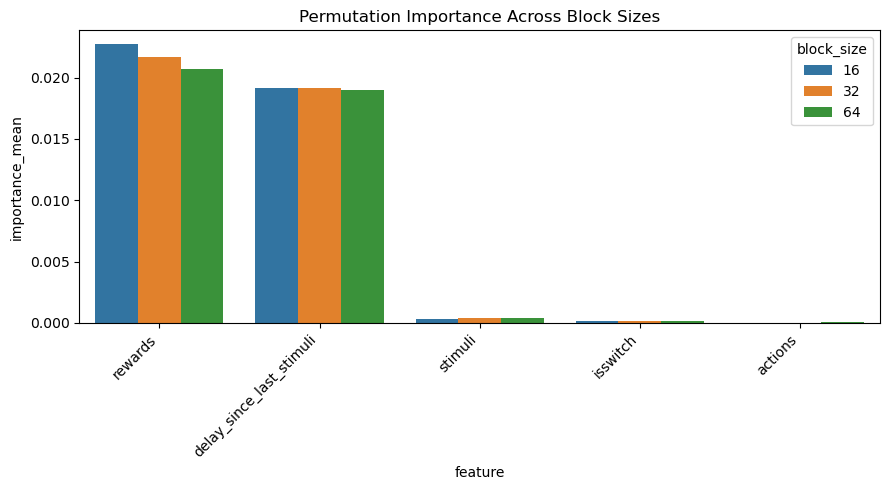

In [8]:
plt.figure(figsize=(9, 5))
sns.barplot(
    data=combined,
    x="feature",
    y="importance_mean",
    hue="block_size"
)
plt.xticks(rotation=45, ha="right")
plt.title("Permutation Importance Across Block Sizes")
plt.tight_layout()
plt.show()

## All time sequences shuffle within sample/participant/agent

In [7]:
# X_test: (500, 936, 5), y_test: (500, 936)
feature_names = feature_list

ranking = permutation_importance_global_sequence(
    model=gru_model,     # already trained once
    X_val=test_features,
    y_val=test_labels,
    feature_names=feature_names,
    n_repeats=3,
    batch_size=64,
    sample_weight=None,  # put mask here if you use padded timesteps
    shuffle_mode="within_sample",
    random_state=123
)

print(ranking)

Permutation feature actions
Permutation loss: 0.004168259911239147
Permutation loss: 0.0041869087144732475
Permutation loss: 0.004150552209466696
Permutation feature rewards
Permutation loss: 0.03058036044239998
Permutation loss: 0.030542153865098953
Permutation loss: 0.03037191741168499
Permutation feature stimuli
Permutation loss: 0.004546891897916794
Permutation loss: 0.004564210306853056
Permutation loss: 0.004544719122350216
Permutation feature isswitch
Permutation loss: 0.004254962783306837
Permutation loss: 0.004255539271980524
Permutation loss: 0.00424170820042491
Permutation feature delay_since_last_stimuli
Permutation loss: 0.021030962467193604
Permutation loss: 0.02089712768793106
Permutation loss: 0.020660346373915672
                    feature  importance_mean  importance_std  baseline_loss  \
0                   rewards         0.026385        0.000091       0.004113   
1  delay_since_last_stimuli         0.016750        0.000153       0.004113   
2                   sti

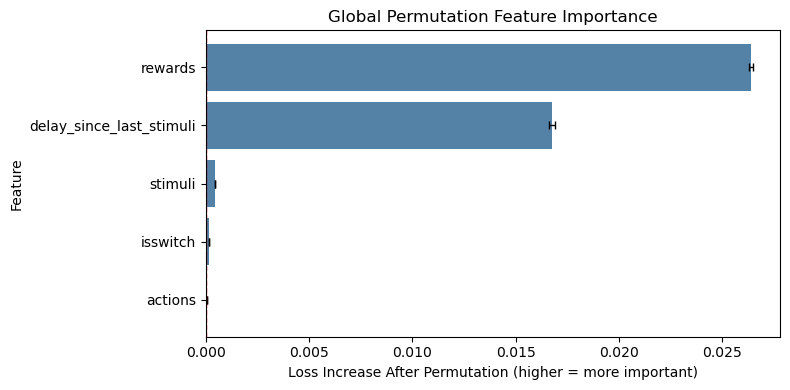

In [8]:
plt.figure(figsize=(8, 4))
ax = sns.barplot(
    data=ranking,
    x="importance_mean",
    y="feature",
    color="steelblue"
)
# add error bars if present
if "importance_std" in ranking.columns:
    ax.errorbar(
        x=ranking["importance_mean"],
        y=range(len(ranking)),
        xerr=ranking["importance_std"],
        fmt="none",
        ecolor="black",
        capsize=3,
        lw=1
    )
ax.axvline(0, color="red", linestyle="--", linewidth=1)
ax.set_title("Global Permutation Feature Importance")
ax.set_xlabel("Loss Increase After Permutation (higher = more important)")
ax.set_ylabel("Feature")
plt.tight_layout()
plt.show()